In [1]:
print("langgraph project...!")

langgraph project...!


In [ ]:
from typing import List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field


In [3]:
class Analyst(BaseModel):
    name: str = Field(description="Name of the analyst.")
    role: str = Field(description="Role of the analyst in the context of the topic.")
    affiliation: str = Field(description="Primary affiliation of the analyst.")
    description: str = Field(description="Description of the analyst focus, concerns, and motives.")
    
    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole: {self.role}\nAffiliation: {self.affiliation}\nDescription: {self.description}\n"
    

In [4]:
analyst=Analyst(
    name="John Doe",
    role="Cybersecurity Analyst",
    affiliation="Tech University",
    description="John is a cybersecurity analyst with a focus on threat intelligence and incident response. He is concerned about the increasing sophistication of cyber threats and is motivated to protect organizations from cyber attacks."
)

In [5]:
analyst

Analyst(name='John Doe', role='Cybersecurity Analyst', affiliation='Tech University', description='John is a cybersecurity analyst with a focus on threat intelligence and incident response. He is concerned about the increasing sophistication of cyber threats and is motivated to protect organizations from cyber attacks.')

In [6]:
analyst.name

'John Doe'

In [8]:
print(analyst.persona)

Name: John Doe
Role: Cybersecurity Analyst
Affiliation: Tech University
Description: John is a cybersecurity analyst with a focus on threat intelligence and incident response. He is concerned about the increasing sophistication of cyber threats and is motivated to protect organizations from cyber attacks.



In [9]:
class Perspectives(BaseModel):
       analysts: List[Analyst] = Field(description="Comprehensive list of analysts with their roles and affiliations.")

In [ ]:
# input to the state
class GenerateAnalystsState(TypedDict):
    topic: str #research topic
    max_analysts: int # number of analyst
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions

In [11]:
GenerateAnalystsState(
    topic = "finance",
    max_analysts= 5,
    human_analyst_feedback= "give the real info",  
)

{'topic': 'finance',
 'max_analysts': 5,
 'human_analyst_feedback': 'give the real info'}

In [12]:
analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

In [13]:
print([analyst_instructions.format(
        topic="education",
        max_analysts=4,
        human_analyst_feedback="please exaplain only on AI"
        
        )] + ["Generate the set of analysts."])

['You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:\n\n1. First, review the research topic:\neducation\n\n2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: \n\nplease exaplain only on AI\n\n3. Determine the most interesting themes based upon documents and / or feedback above.\n\n4. Pick the top 4 themes.\n\n5. Assign one analyst to each theme.', 'Generate the set of analysts.']


['You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:\n\n1. First, review the research topic:\neducation\n\n2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: \n\nplease exaplain only on AI\n\n3. Determine the most interesting themes based upon documents and / or feedback above.\n\n4. Pick the top 4 themes.\n\n5. Assign one analyst to each theme.', 'Generate the set of analysts.']

In [ ]:
import os
from langchain.chat_models import init_chat_model

os.environ["OPENAI_API_KEY"] = ""

llm = init_chat_model("gpt-5.2")

In [26]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import AIMessage,HumanMessage , SystemMessage
from langgraph.checkpoint.memory import MemorySaver

def create_analyst(state:GenerateAnalystsState):
    """
    it is creating my analyst
    
    """
    topic = state["topic"]
    #max_analysts = state["max_analysts"]
    max_analysts = state.get("max_analysts", "")
    human_analyst_feedback = state.get("human_analyst_feedback","")
    
    structured_llm = llm.with_structured_output(Perspectives)
    
    system_messages = analyst_instructions.format(
        topic=topic,
        max_analysts=max_analysts,
        human_analyst_feedback=human_analyst_feedback
        
        )
    analysts = structured_llm.invoke([SystemMessage(content=system_messages)]+ [HumanMessage(content="Generate the set of analysts.")])
    
    # Write the list of analysis to state
    return {"analysts": analysts.analysts}
    

In [27]:
create_analyst(
    {'topic': 'health',
    'max_analysts': 1,
    'human_analyst_feedback': 'give the real info'}
    )

{'analysts': [Analyst(name='Dr. Maya Chen', role='Evidence-Based Health Analyst (Clinical & Public Health)', affiliation='Independent, evidence-based health research group', description="Focuses on providing 'real info' by translating medical research into accurate, practical guidance. Prioritizes high-quality evidence (systematic reviews, RCTs, clinical guidelines), quantifies benefits/harms, and flags uncertainty, conflicts of interest, and misleading health claims. Motivated to correct misinformation and help audiences make safer decisions about prevention, screening, treatments, lifestyle, and supplements.")]}

In [28]:
def human_feedback(state):
    """ No-op node that should be interrupted on """
    pass

In [29]:
def should_continue(state):
    feedback = (state.get("human_analyst_feedback") or "").strip().lower()
    if feedback and feedback not in ["", "none", "skip", "done", "continue"]:
        return "create_analyst"
    return END


In [30]:
builder = StateGraph(GenerateAnalystsState)

In [31]:
builder.add_node("create_analyst",create_analyst)
builder.add_node("human_feedback", human_feedback)

In [32]:
builder.add_edge(START,"create_analyst")
builder.add_edge("create_analyst", "human_feedback")
builder.add_conditional_edges("human_feedback",
                        should_continue,
                        ["create_analyst",
                        END])

In [33]:
memory = MemorySaver()
graph = builder.compile(interrupt_before= ["human_feedback"],checkpointer= memory)

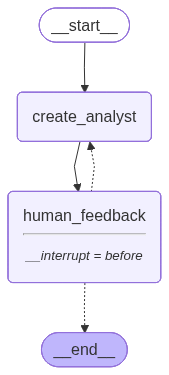

In [34]:
graph

In [35]:
topic = "the benefits of adopting Langgraph as an agent framework"
max_analysts = 2
thread =  {"configurable":{"thread_id":1}}
for event in graph.stream({"topic":topic,
              "max_analysts":max_analysts},
             thread,
             stream_mode= "values"):
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  
            
        

Name: Maya Chen
Affiliation: Platform Engineering / AI Infrastructure
Role: LLM Systems Architect (Agent Orchestration & Reliability)
Description: Focuses on the engineering benefits of adopting LangGraph for building production-grade agent systems: explicit state machines/graphs, deterministic control flow, checkpointing and resumability, human-in-the-loop gates, observability, testing, and failure isolation. Evaluates how LangGraph compares to ad-hoc tool-calling loops and other agent frameworks in terms of correctness, debuggability, and operational reliability at scale.
--------------------------------------------------
Name: Rafael Singh
Affiliation: Applied AI Product / Enterprise Transformation Office
Role: Product & Delivery Lead (Time-to-Value, Governance, and Maintainability)
Description: Assesses LangGraph from a productization and organizational adoption lens: speed of iteration, reuse of agent components, team collaboration patterns, governance and compliance controls, lon

In [36]:
state = graph.get_state(thread)

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


In [37]:
state

StateSnapshot(values={'topic': 'the benefits of adopting Langgraph as an agent framework', 'max_analysts': 2, 'analysts': [Analyst(name='Maya Chen', role='LLM Systems Architect (Agent Orchestration & Reliability)', affiliation='Platform Engineering / AI Infrastructure', description='Focuses on the engineering benefits of adopting LangGraph for building production-grade agent systems: explicit state machines/graphs, deterministic control flow, checkpointing and resumability, human-in-the-loop gates, observability, testing, and failure isolation. Evaluates how LangGraph compares to ad-hoc tool-calling loops and other agent frameworks in terms of correctness, debuggability, and operational reliability at scale.'), Analyst(name='Rafael Singh', role='Product & Delivery Lead (Time-to-Value, Governance, and Maintainability)', affiliation='Applied AI Product / Enterprise Transformation Office', description='Assesses LangGraph from a productization and organizational adoption lens: speed of ite

In [38]:
state.values

{'topic': 'the benefits of adopting Langgraph as an agent framework',
 'max_analysts': 2,
 'analysts': [Analyst(name='Maya Chen', role='LLM Systems Architect (Agent Orchestration & Reliability)', affiliation='Platform Engineering / AI Infrastructure', description='Focuses on the engineering benefits of adopting LangGraph for building production-grade agent systems: explicit state machines/graphs, deterministic control flow, checkpointing and resumability, human-in-the-loop gates, observability, testing, and failure isolation. Evaluates how LangGraph compares to ad-hoc tool-calling loops and other agent frameworks in terms of correctness, debuggability, and operational reliability at scale.'),
  Analyst(name='Rafael Singh', role='Product & Delivery Lead (Time-to-Value, Governance, and Maintainability)', affiliation='Applied AI Product / Enterprise Transformation Office', description='Assesses LangGraph from a productization and organizational adoption lens: speed of iteration, reuse of 

In [39]:
state.next

('human_feedback',)

In [41]:
state.config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1302f5-4c7c-6905-8001-1027ed0ac055'}}

In [43]:
graph.update_state(thread,
                   {"human_analyst_feedback":"add something from the startup perspective and focus on the latest enterprise application"},as_node="human_feedback"
                   )

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1302fe-aa87-6d81-8003-afdbacaec0ba'}}

In [44]:
for event in graph.stream({"topic":topic,
              "max_analysts":max_analysts},
             thread,
             stream_mode= "values"):
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


Name: Maya Chen
Affiliation: Platform Engineering / AI Infrastructure
Role: LLM Systems Architect (Agent Orchestration & Reliability)
Description: Focuses on the engineering benefits of adopting LangGraph for building production-grade agent systems: explicit state machines/graphs, deterministic control flow, checkpointing and resumability, human-in-the-loop gates, observability, testing, and failure isolation. Evaluates how LangGraph compares to ad-hoc tool-calling loops and other agent frameworks in terms of correctness, debuggability, and operational reliability at scale.
--------------------------------------------------
Name: Rafael Singh
Affiliation: Applied AI Product / Enterprise Transformation Office
Role: Product & Delivery Lead (Time-to-Value, Governance, and Maintainability)
Description: Assesses LangGraph from a productization and organizational adoption lens: speed of iteration, reuse of agent components, team collaboration patterns, governance and compliance controls, lon

SECOND WORK FLOW

In [ ]:
# TOOLS

from langchain_community.document_loaders import WikipediaLoader

docs = WikipediaLoader(query="LangGraph").load()
print(docs[0].page_content[:500])

LangChain is a software framework that helps facilitate the integration of large language models (LLMs) into applications. As a language model integration framework, LangChain's use-cases largely overlap with those of language models in general, including document analysis and summarization, chatbots, and code analysis.


== History ==
LangChain was launched in October 2022 as an open source project by Harrison Chase, while working at machine learning startup Robust Intelligence. In April 2023, 


In [48]:
#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

from langchain_community.tools.tavily_search import TavilySearchResults

search = TavilySearchResults(
    tavily_api_key="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"
)

result = search.invoke("latest news about AI")
print(result)

[{'title': 'Latest AI News and AI Breakthroughs that Matter Most: 2026', 'url': 'https://www.crescendo.ai/news/latest-ai-news-and-updates', 'content': 'Date: January 29, 2026\n\nSummary: Amazon has announced a fresh wave of layoffs impacting approximately 16,000 corporate employees, citing a strategic shift toward AI-driven automation and "agentic" workflows. The job cuts primarily target middle management and administrative roles that have become redundant as the company integrates more sophisticated AI systems to handle logistics planning, vendor relations, and internal reporting. While Amazon continues to hire for AI-specialized engineering roles, the move reflects a broader industry trend of "re-skilling" and restructuring as tech giants prioritize high-efficiency AI infrastructure over traditional staffing models. The company stated these cuts are necessary to remain agile in a rapidly evolving, AI-first retail landscape. [...] Date: January 14, 2026\n\nSummary: AstraZeneca has an

In [54]:
class InterviewState(BaseModel):
    pass
def ask_question(state: InterviewState):
    """Ask a question to the analyst."""
    pass
def search_web(state: InterviewState):
    """Search the web for relevant information."""
    pass
def search_wikipedia(state: InterviewState):
    """Search Wikipedia for relevant information."""
    pass
def generate_answer(state: InterviewState):
    """Generate an answer based on the information gathered."""
    pass
def save_interview(state: InterviewState):
    """Save the interview for future reference."""
    pass
def write_section(state: InterviewState):
    """Write a section of the final report."""
    pass
def route_messages(state: InterviewState):
    """Route messages based on the state of the interview."""
    pass

interview_builder = StateGraph(InterviewState)

interview_builder.add_node("ask_question",ask_question)
interview_builder.add_node("search_web",search_web)
interview_builder.add_node("search_wikipedia",search_wikipedia)
interview_builder.add_node("generate_answer",generate_answer)
interview_builder.add_node("save_interview",save_interview)
interview_builder.add_node("write_section",write_section)

interview_builder.add_edge(START,"ask_question")
interview_builder.add_edge("ask_question","search_web")
interview_builder.add_edge("ask_question","search_wikipedia")
interview_builder.add_edge("search_web","generate_answer")
interview_builder.add_edge("search_wikipedia","generate_answer")
interview_builder.add_conditional_edges("generate_answer",
                           route_messages,
                           ["ask_question",
                            "save_interview"])
interview_builder.add_edge("save_interview","write_section")
interview_builder.add_edge("write_section",END)


In [55]:
graph=interview_builder.compile()

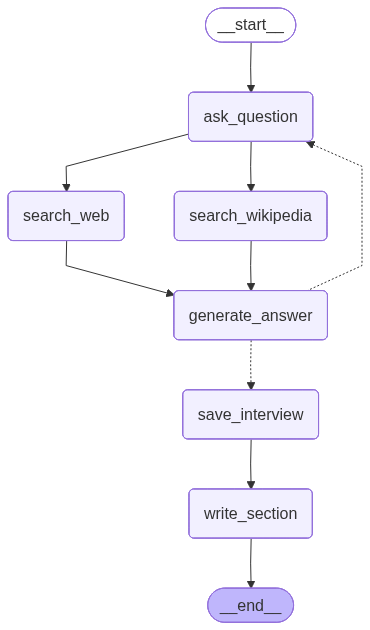

In [56]:
graph